# Modelo Red Neuronal con datos de viajes por minuto entre estaciones

Igual que el 7_6 pero dividiendo más aún la clase 1

In [140]:
version = "7_7"

In [141]:
import pickle
import pandas as pd
import numpy as np
import json

pd.set_option("display.max_rows", None)   # Muestra todas las filas
pd.set_option("display.max_columns", None)  # Muestra todas las columnas
pd.set_option("display.width", None)     # No corta la tabla en varias líneas
pd.set_option("display.max_colwidth", None)  # Muestra el contenido de celdas completo

In [142]:
with open("../../data/normalized/df_normalized.pk1", "rb") as f:
    df_data = pickle.load(f)

In [143]:
df_model = df_data.drop(columns=[
    "ride_id",
    "ended_at",
    "time_hms_ms",
    "member_casual",
    "start_station_id",
    "end_station_id",
    "month",
    "day",
    "temperature",
    "wind_speed",
    "precipitation",
    "relative_humidity",
    "snow_depth",
    "hour_float"
])

In [144]:
# Se redonde al minuto mas cercano
df_data["started_minute"] = df_data["started_at"].dt.round("min")

In [145]:
df_agg = df_data.groupby([
    "start_station_idx",
    "end_station_idx",
    "started_minute"
]).agg(
    n_viajes=("ride_id", "count"),
    year=("year", "first"),
    temp_std=("temp_std", "first"),
    wind_std=("wind_std", "first"),
    rel_humidity_std=("rel_humidity_std", "first"),
    precipitation_std=("precipitation_std", "first"),
    snow_depth_std=("snow_depth_std", "first"),
    hour_sin=("hour_sin", "first"),
    hour_cos=("hour_cos", "first"),
    month_sin=("month_sin", "first"),
    month_cos=("month_cos", "first"),
    event=("event", "any"),  # True si al menos un dato es true
    normal_day=("day_type_Normal", "any"),  # True si al menos un dato es true
    weekend_day=("day_type_Weekend", "any"),  # True si al menos un dato es true
    holiday_day=("day_type_Holiday", "any"),  # True si al menos un dato es true
    #member_casual=("member_casual_bool", "any"),  # True si al menos un dato es true
    #classic_bike=("rideable_type_classic_bike", "any"),  # True si al menos un dato es true
    #docked_bike=("rideable_type_docked_bike", "any"),  # True si al menos un dato es true
    #electric_bike=("rideable_type_electric_bike", "any"),  # True si al menos un dato es true
    #duration_min_mean=("duration_min", "mean"),
).reset_index()

In [146]:
df_agg.describe()

,start_station_idx,end_station_idx,started_minute,n_viajes,year,temp_std,wind_std,rel_humidity_std,precipitation_std,snow_depth_std,hour_sin,hour_cos,month_sin,month_cos
count,9.073410e+06,9.073410e+06,9073410,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06
mean,1.451035e+03,1.451958e+03,2023-03-15 06:23:51.479779072,1.048204e+00,2.022696e+03,-1.495024e-02,-1.812192e-03,8.774936e-03,4.883809e-05,1.967412e-03,-3.315338e-01,-2.758742e-01,-9.310089e-02,-2.660463e-01
min,0.000000e+00,0.000000e+00,2022-01-01 00:00:00,1.000000e+00,2.022000e+03,-4.191219e+00,-1.996051e+00,-2.519273e+00,-9.970427e-02,-5.614845e-02,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00
25%,1.358000e+03,1.358000e+03,2022-08-06 17:06:00,1.000000e+00,2.022000e+03,-7.493464e-01,-6.917960e-01,-7.628922e-01,-9.970427e-02,-5.614845e-02,-9.362641e-01,-8.029042e-01,-8.660254e-01,-8.660254e-01
50%,1.447000e+03,1.448000e+03,2023-04-13 19:23:00,1.000000e+00,2.023000e+03,1.895027e-01,-8.000990e-02,1.485145e-02,-9.970427e-02,-5.614845e-02,-6.025698e-01,-3.916012e-01,-2.449294e-16,-5.000000e-01
75%,1.565000e+03,1.565000e+03,2023-09-10 20:57:00,1.000000e+00,2.023000e+03,7.707278e-01,6.198615e-01,7.945084e-01,-9.970427e-02,-5.614845e-02,2.005080e-01,1.192704e-01,5.000000e-01,5.000000e-01
max,1.911000e+03,1.911000e+03,2024-06-01 00:00:00,9.000000e+00,2.024000e+03,2.175728e+00,5.576328e+00,2.359562e+00,6.945283e+01,7.287764e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
std,2.191965e+02,2.176947e+02,NaN,2.348621e-01,6.859159e-01,1.003718e+00,1.000607e+00,9.993908e-01,9.976954e-01,1.017557e+00,6.781692e-01,5.950339e-01,7.072976e-01,6.482914e-01


In [147]:
df_agg.iloc[10000:10010]

,start_station_idx,end_station_idx,started_minute,n_viajes,year,temp_std,wind_std,rel_humidity_std,precipitation_std,snow_depth_std,hour_sin,hour_cos,month_sin,month_cos,event,normal_day,weekend_day,holiday_day
10000,5,1362,2022-06-21 00:57:00,1,2022,1.595537,0.115036,-1.872588,-0.099704,-0.056148,0.246788,0.969070,1.224647e-16,-1.000000e+00,False,True,False,False
10001,5,1362,2022-06-30 23:12:00,1,2022,1.607251,1.549199,-1.694654,-0.099704,-0.056148,-0.208836,0.977951,1.224647e-16,-1.000000e+00,False,True,False,False
10002,5,1362,2022-07-06 21:22:00,1,2022,0.976758,0.449277,0.293232,-0.099704,-0.056148,-0.636639,0.771162,-5.000000e-01,-8.660254e-01,False,True,False,False
10003,5,1362,2022-07-10 10:15:00,1,2022,0.056858,-1.307653,1.096805,-0.099704,-0.056148,0.442419,-0.896808,-5.000000e-01,-8.660254e-01,True,False,True,False
10004,5,1362,2022-07-14 18:18:00,1,2022,1.028438,-0.764584,-0.615571,-0.099704,-0.056148,-0.996974,0.077734,-5.000000e-01,-8.660254e-01,False,True,False,False
10005,5,1362,2022-08-13 14:58:00,1,2022,0.801047,0.344502,-0.797331,-0.099704,-0.056148,-0.700857,-0.713301,-8.660254e-01,-5.000000e-01,False,False,True,False
10006,5,1362,2022-08-22 11:15:00,1,2022,0.212242,-0.741637,1.378055,-0.099704,-0.056148,0.196731,-0.980458,-8.660254e-01,-5.000000e-01,False,True,False,False
10007,5,1362,2022-09-03 13:02:00,1,2022,0.660994,-0.630728,0.861473,-0.099704,-0.056148,-0.266257,-0.963902,-1.000000e+00,-1.836970e-16,True,False,True,False
10008,5,1362,2022-09-20 17:01:00,1,2022,1.279257,0.561730,-0.131514,-0.099704,-0.056148,-0.966768,-0.255657,-1.000000e+00,-1.836970e-16,False,True,False,False
10009,5,1362,2022-10-04 08:27:00,1,2022,-0.664936,-1.996051,0.989662,-0.099704,-0.056148,0.800339,-0.599548,-8.660254e-01,5.000000e-01,False,True,False,False


In [148]:
df_agg['n_viajes'].value_counts(normalize=False)

n_viajes
1    8671457
2     372173
3      24990
4       4098
5        565
6        103
7         19
8          4
9          1
Name: count, dtype: int64

Claramente hay un desajuste de datos

## Se divide la cantidad de viajes 1 en varias subclases

In [149]:
df_class_1 = df_agg[df_agg['n_viajes'] == 1]

In [150]:
with open("../../data/normalized/le_station_encoder.pkl", "rb") as f:
    le_station = pickle.load(f)
    
num_stations = len(le_station.classes_)

### Se divide aún más la clase 1

In [151]:
second_sep = (num_stations/2) + num_stations/4

df_class_1 = df_agg[df_agg['n_viajes'] == 1].copy()

def assign_subclass(row):
    if row['start_station_idx'] < (num_stations / 2): # Estaciones "bajas"
        return 1  
    else:
        if row['start_station_idx'] < second_sep: # Estaciones medias
            return assign_per_hour(row, 0)
        else: # Estaciones altas
            return assign_per_hour(row, 5)  # Estaciones "altas"
        
def assign_per_hour(row, increment):
    # Division por hora
    h = row['started_minute'].hour
    if h <= 9:
        return 2 + increment
    elif h <= 13:
        return 3 + increment
    elif h <= 17:
        return 4 + increment    
    elif h <= 20:
        return 5 + increment        
    else:
        return 6 + increment

df_agg.loc[df_class_1.index, 'subclass'] = df_class_1.apply(assign_subclass, axis=1)

# Revisar conteo por subclase
print(df_agg['subclass'].value_counts())

subclass
9.0     1480821
4.0     1286187
7.0     1000273
8.0      973262
10.0     867487
2.0      819797
3.0      775563
5.0      689170
11.0     353927
6.0      280096
1.0      144874
Name: count, dtype: int64


### Se añaden el resto de clases (viajes) que faltan

Se mueve el resto de clases

In [152]:
mask = df_agg['n_viajes'] > 1
df_agg.loc[mask, 'subclass'] = df_agg.loc[mask, 'n_viajes'] + 10

# Revisar conteo por subclase
print(df_agg['subclass'].value_counts())


subclass
9.0     1480821
4.0     1286187
7.0     1000273
8.0      973262
10.0     867487
2.0      819797
3.0      775563
5.0      689170
12.0     372173
11.0     353927
6.0      280096
1.0      144874
13.0      24990
14.0       4098
15.0        565
16.0        103
17.0         19
18.0          4
19.0          1
Name: count, dtype: int64


Se agrupan los viajes 8, 9 y 7 en una sola clase

In [153]:
mask = df_agg['subclass'] >= 15
df_agg.loc[mask, 'subclass'] = 15

# Revisar conteo por subclase
print(df_agg['subclass'].value_counts())

subclass
9.0     1480821
4.0     1286187
7.0     1000273
8.0      973262
10.0     867487
2.0      819797
3.0      775563
5.0      689170
12.0     372173
11.0     353927
6.0      280096
1.0      144874
13.0      24990
14.0       4098
15.0        692
Name: count, dtype: int64


In [154]:
# convertir a entero
df_agg['subclass'] = df_agg['subclass'].astype(int)

## Simulación de datos con SMOT de las clases minoritarias

Se intenta no igualar las clases porque no tendria sentido en clases tan desvalanceadas por eso se limita el SMOTE

In [155]:
df_agg.dtypes

start_station_idx             int64
end_station_idx               int64
started_minute       datetime64[ns]
n_viajes                      int64
year                          int64
temp_std                    float64
wind_std                    float64
rel_humidity_std            float64
precipitation_std           float64
snow_depth_std              float64
hour_sin                    float64
hour_cos                    float64
month_sin                   float64
month_cos                   float64
event                          bool
normal_day                     bool
weekend_day                    bool
holiday_day                    bool
subclass                      int64
dtype: object

In [156]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from collections import Counter

# --- 1. Separar features y target ---
df = df_agg.copy()

data_raw = df.drop(columns=['started_minute'])  # quitar datetime
y = df['subclass'].astype(int)

print("Antes:", Counter(y))

# --- 3. Ajustar estrategia SMOTE ---
# Como tus clases 7 y 8 tienen muy pocos ejemplos,
# usamos k_neighbors=2 y fijamos targets razonables.

target_sizes = {
    13: 40_000,
    14: 10_000,
    15: 5_000
}

sm = SMOTE(
    sampling_strategy=target_sizes,
    k_neighbors=2,
    random_state=42
)

# --- 4. Aplicar SMOTE ---
data_smote, y_smote = sm.fit_resample(data_raw, y)

print("Después:", Counter(y_smote))

# 4. Reconstruir DataFrame final
df_smote = pd.DataFrame(data_smote, columns=df_agg.columns.drop("started_minute"))
df_smote['subclass'] = y_smote


Antes: Counter({9: 1480821, 4: 1286187, 7: 1000273, 8: 973262, 10: 867487, 2: 819797, 3: 775563, 5: 689170, 12: 372173, 11: 353927, 6: 280096, 1: 144874, 13: 24990, 14: 4098, 15: 692})
Después: Counter({9: 1480821, 4: 1286187, 7: 1000273, 8: 973262, 10: 867487, 2: 819797, 3: 775563, 5: 689170, 12: 372173, 11: 353927, 6: 280096, 1: 144874, 13: 40000, 14: 10000, 15: 5000})


In [157]:
# Revisar conteo por subclase
print(df_smote['subclass'].value_counts())

subclass
9     1480821
4     1286187
7     1000273
8      973262
10     867487
2      819797
3      775563
5      689170
12     372173
11     353927
6      280096
1      144874
13      40000
14      10000
15       5000
Name: count, dtype: int64


## Obtención de datos

In [158]:
x_context = df_smote.drop(columns=[
    "n_viajes",
    #"started_minute",
    "start_station_idx",
    "end_station_idx",
    "subclass",
])

x_start = df_smote[[
    "start_station_idx",
]]

x_end = df_smote[[
    "end_station_idx",
]]

y = df_smote["subclass"]

In [159]:
x_context.head()

,year,temp_std,wind_std,rel_humidity_std,precipitation_std,snow_depth_std,hour_sin,hour_cos,month_sin,month_cos,event,normal_day,weekend_day,holiday_day
0,2022,-1.379839,1.021427,1.326397,-0.099704,-0.056148,-0.416215,-0.909266,0.866025,5.000000e-01,False,False,False,True
1,2022,-0.612834,-0.276355,-0.807078,-0.099704,-0.056148,-0.717569,-0.696487,1.000000,6.123234e-17,False,False,True,False
2,2022,-1.156238,4.113864,0.687365,-0.099704,-0.056148,0.281155,-0.959662,1.000000,6.123234e-17,False,False,True,False
3,2022,-0.424108,-0.883141,-1.019270,-0.099704,-0.056148,-0.972183,-0.234223,1.000000,6.123234e-17,False,False,True,False
4,2022,-0.410327,-0.825775,-1.038403,-0.099704,-0.056148,-0.976781,-0.214238,1.000000,6.123234e-17,False,False,True,False


In [160]:
x_start.head()

,start_station_idx
0,0
1,0
2,0
3,0
4,0


In [161]:
x_end.head()

,end_station_idx
0,0
1,0
2,0
3,0
4,0


In [162]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: subclass, dtype: int64

## Compruebo que de verdad hay viajes de ida y vuelta con el mismo id

In [163]:
df_check = df_data["start_station_idx"] == df_data["end_station_idx"]

In [164]:
# Contar numero de True
n_same_station = df_check.sum()
print(f"Número de viajes de ida y vuelta con la misma estación de inicio y fin: {n_same_station}")

Número de viajes de ida y vuelta con la misma estación de inicio y fin: 615646


## Se continua diviendo los datos

In [165]:
with open("../../data/normalized/le_station_encoder.pkl", "rb") as f:
    le_station = pickle.load(f)
    
len(le_station.classes_)

1912

In [166]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: subclass, dtype: int64

In [167]:
# El target empieza en 1 → lo pasamos a 0
y_cls = y - 1

num_classes = y_cls.max() + 1
print("Clases totales:", num_classes)

Clases totales: 15


In [168]:
from sklearn.model_selection import train_test_split

x_ctx_train, x_ctx_test, x_start_train, x_start_test, x_end_train, x_end_test, y_train, y_test = \
    train_test_split(x_context, x_start, x_end, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

x_ctx_train, x_ctx_val, x_start_train, x_start_val, x_end_train, x_end_val, y_train, y_val = \
    train_test_split(x_ctx_train, x_start_train, x_end_train, y_train, test_size=0.2, random_state=42, stratify=y_train)


## Se calcula class_weight para evitar colpaso por dominación de la clase 1

In [169]:
y_train.head()

6741783    11
6931667     6
4823053     6
7199653     8
2006201    11
Name: subclass, dtype: int64

In [170]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes_present = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes_present,
    y=y_train
)

class_weights = {i: w for i, w in zip(classes_present, class_weights)}
print(class_weights)


{np.int64(0): np.float64(4.186932559669539), np.int64(1): np.float64(0.739909276307012), np.int64(2): np.float64(0.7821101619792087), np.int64(3): np.float64(0.4716072209533991), np.int64(4): np.float64(0.8801529919355021), np.int64(5): np.float64(2.165591145920496), np.int64(6): np.float64(0.606410444660358), np.int64(7): np.float64(0.6232401703679801), np.int64(8): np.float64(0.4096207131597107), np.int64(9): np.float64(0.6992323376417527), np.int64(10): np.float64(1.7138375552945955), np.int64(11): np.float64(1.6298257693438012), np.int64(12): np.float64(15.1643828125), np.int64(13): np.float64(60.65753125), np.int64(14): np.float64(121.3150625)}


In [171]:
print("Clases en train:", np.unique(y_train))
print("Clases totales:", np.arange(num_classes))


Clases en train: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Clases totales: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]


## Se continua con la creación del modelo

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input, regularizers
from tensorflow.keras.optimizers import Adam
import numpy as np

num_stations = len(le_station.classes_)
num_features = x_context.shape[1]

l2_reg = 1e-4
drop_rate = 0.3

# Inputs
input_start = Input(shape=(1,), name='start_station')
input_end = Input(shape=(1,), name='end_station')
input_context = Input(shape=(num_features,), name='context')

# Embeddings
embed_dim = int(np.ceil(np.sqrt(num_stations)))
embed_start = layers.Embedding(num_stations, embed_dim,embeddings_regularizer=regularizers.l2(l2_reg))(input_start)
embed_end = layers.Embedding(num_stations, embed_dim,embeddings_regularizer=regularizers.l2(l2_reg))(input_end)

# Flatten
flat_start = layers.Flatten()(embed_start)
flat_end = layers.Flatten()(embed_end)

# Concatenate
x = layers.Concatenate()([flat_start, flat_end, input_context])

# Dense Block 1
x = layers.Dense(128,kernel_regularizer=regularizers.l2(l2_reg))(x)
#x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)
x = layers.Dropout(drop_rate)(x)

# Dense Block 2
x = layers.Dense(64,kernel_regularizer=regularizers.l2(l2_reg))(x)
#x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)
x = layers.Dropout(drop_rate)(x)

# Dense Block 3
x = layers.Dense(32,kernel_regularizer=regularizers.l2(l2_reg))(x)
#x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)
x = layers.Dropout(drop_rate)(x)

# Output
output = layers.Dense(num_classes, activation='softmax')(x)

# Model
model = Model(inputs=[input_start, input_end, input_context], outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ start_station       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ end_station         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 1, 44)     │     84,128 │ start_station[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 1, 44)     │     84,128 │ end_station[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 44)        │          0 │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 44)        │          0 │ embedding_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context             │ (None, 14)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 102)       │          0 │ flatten_4[0][0],  │
│ (Concatenate)       │                   │            │ flatten_5[0][0],  │
│                     │                   │            │ context[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 128)       │     13,184 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 128)       │          0 │ dense_8[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 128)       │          0 │ leaky_re_lu_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │      8,256 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 64)        │          0 │ dense_9[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 64)        │          0 │ leaky_re_lu_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 32)        │      2,080 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_8       │ (None, 32)        │          0 │ dense_10[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 32)        │          0 │ leaky_re_lu_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 15)        │        495 │ dropout_8[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 192,271 (751.06 KB)

 Trainable params: 192,271 (751.06 KB)

 Non-trainable params: 0 (0.00 B)

In [173]:
# Entrenamiento
history = model.fit(
    {'start_station': x_start_train, 'end_station': x_end_train, 'context': x_ctx_train},
    y_train,
    validation_data=(
        {'start_station': x_start_val, 'end_station': x_end_val, 'context': x_ctx_val},
        y_val
    ),    
    batch_size=256,
    epochs=50,
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )
    ]
)


Epoch 1/50
22747/22747 ━━━━━━━━━━━━━━━━━━━━ 55s 2ms/step - accuracy: 0.3259 - loss: 9.7513 - val_accuracy: 0.8586 - val_loss: 0.7877
Epoch 2/50
22747/22747 ━━━━━━━━━━━━━━━━━━━━ 53s 2ms/step - accuracy: 0.7519 - loss: 1.3073 - val_accuracy: 0.8744 - val_loss: 0.6707
Epoch 3/50
22747/22747 ━━━━━━━━━━━━━━━━━━━━ 59s 3ms/step - accuracy: 0.7937 - loss: 1.2036 - val_accuracy: 0.8950 - val_loss: 0.6137
Epoch 4/50
22747/22747 ━━━━━━━━━━━━━━━━━━━━ 87s 3ms/step - accuracy: 0.8141 - loss: 1.1491 - val_accuracy: 0.9013 - val_loss: 0.6279
Epoch 5/50
22747/22747 ━━━━━━━━━━━━━━━━━━━━ 65s 3ms/step - accuracy: 0.8286 - loss: 1.1186 - val_accuracy: 0.8937 - val_loss: 0.5132
Epoch 6/50
22747/22747 ━━━━━━━━━━━━━━━━━━━━ 65s 3ms/step - accuracy: 0.8380 - loss: 1.0958 - val_accuracy: 0.9249 - val_loss: 0.5126
Epoch 7/50
22747/22747 ━━━━━━━━━━━━━━━━━━━━ 67s 3ms/step - accuracy: 0.8470 - loss: 1.0751 - val_accuracy: 0.9089 - val_loss: 0.5188
Epoch 8/50
22747/22747 ━━━━━━━━━━━━━━━━━━━━ 65s 3ms/step - accuracy: 

In [174]:
import matplotlib.pyplot as plt

def show_history(history, model_name: str):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))  # 2 filas, 1 columna

    # Pérdida (loss)
    ax1.plot(history.history['loss'],     label='Training Loss',  color='green')
    ax1.plot(history.history['val_loss'], label='Validation Loss', color='blue')
    ax1.set_title('Loss evolution')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Precisión (accuracy)
    ax2.plot(history.history['accuracy'],     label='Training Accuracy',  color='green')
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')
    ax2.set_title('Accuracy evolution')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    # Título global
    fig.suptitle(model_name, fontsize=16)

    # Ajustar márgenes
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

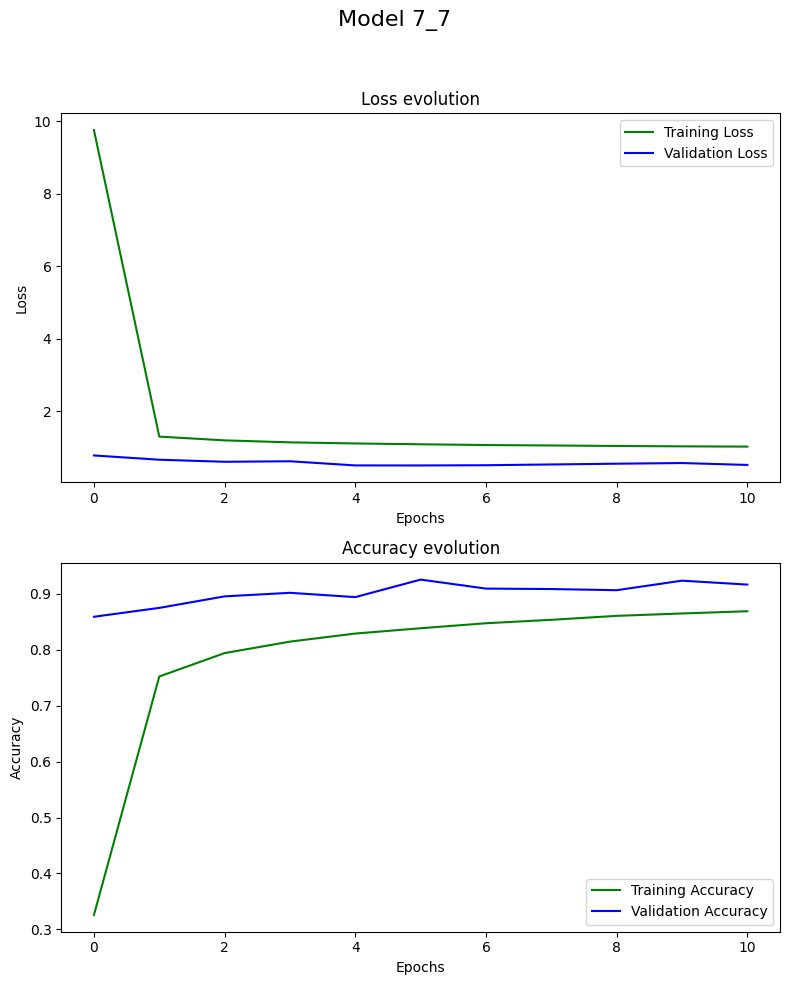

In [175]:
show_history(history, f"Model {version}")

In [176]:
model.save(f"model_{version}.keras")

with open(f'history_{version}.json', 'w') as f:
    json.dump(history.history, f)

## Evaluación del modelo

In [177]:
# ---------- Evaluación final sobre el test set real
test_metrics = model.evaluate(
    {'start_station': x_start_test, 'end_station': x_end_test, 'context': x_ctx_test},
    y_test,
    verbose=2
)
print("Test metrics (loss, accuracy):", test_metrics)

56867/56867 - 49s - 868us/step - accuracy: 0.9249 - loss: 0.5127
Test metrics (loss, accuracy): [0.5126921534538269, 0.9248710870742798]


# Prediccion del modelo

In [178]:
# Predicciones como probabilidades
y_pred_probs = model.predict({
    'start_station': x_start,
    'end_station': x_end,
    'context': x_context
}, batch_size=256)

print("Shape de predicciones:", y_pred_probs.shape)
# (num_ejemplos, num_classes)


35542/35542 ━━━━━━━━━━━━━━━━━━━━ 31s 868us/step
Shape de predicciones: (9098630, 15)


In [179]:
# Elegimos la clase con mayor probabilidad
y_pred_classes = np.argmax(y_pred_probs, axis=1)

print("Clases predichas:", np.unique(y_pred_classes))


Clases predichas: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]


In [180]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
acc = accuracy_score(y_cls, y_pred_classes)
print("Accuracy test:", acc)

# Reporte detallado por clase
print(classification_report(y_cls, y_pred_classes))

# Matriz de confusión
cm = confusion_matrix(y_cls, y_pred_classes)
print(cm)


Accuracy test: 0.9248687989290696
              precision    recall  f1-score   support

           0       0.97      0.97      0.97    144874
           1       0.98      0.94      0.96    819797
           2       0.91      0.98      0.94    775563
           3       0.94      0.97      0.95   1286187
           4       0.90      0.98      0.94    689170
           5       0.82      1.00      0.90    280096
           6       0.98      0.93      0.96   1000273
           7       0.92      0.97      0.94    973262
           8       0.93      0.99      0.96   1480821
           9       0.92      0.98      0.95    867487
          10       0.84      0.99      0.91    353927
          11       0.03      0.00      0.00    372173
          12       0.02      0.00      0.00     40000
          13       0.02      0.00      0.00     10000
          14       0.07      0.40      0.12      5000

    accuracy                           0.92   9098630
   macro avg       0.68      0.74      0.70   

## Se elimina la extensión de la categoría 1

In [181]:
y_cls.unique()

array([ 0, 11, 12, 13, 14,  3,  5,  1,  2,  4,  8, 10,  7,  6,  9])

In [182]:
np.unique(y_pred_classes)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [183]:
conteo_clases = y_cls.value_counts()
print(conteo_clases)

subclass
8     1480821
3     1286187
6     1000273
7      973262
9      867487
1      819797
2      775563
4      689170
11     372173
10     353927
5      280096
0      144874
12      40000
13      10000
14       5000
Name: count, dtype: int64


In [184]:
mapping = {
    0: 1,
    1: 1,
    2: 1,
    3: 1,
    4: 1,
    5: 1,
    6: 1,
    7: 1,
    8: 1,
    9: 1,
    10: 1,
    11: 2,
    12: 3,
    13: 4,
    14: 5
}

y_cls_real = y_cls.map(mapping)
y_pred_real = np.vectorize(lambda x: mapping.get(x, x))(y_pred_classes)

print(np.unique(y_pred_real))
print(y_cls_real.unique())


[1 2 3 4 5]
[1 2 3 4 5]


In [185]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
acc = accuracy_score(y_cls_real, y_pred_real)
print("Accuracy test:", acc)

# Reporte detallado por clase
print(classification_report(y_cls_real, y_pred_real))

# Matriz de confusión
cm = confusion_matrix(y_cls_real, y_pred_real)
print(cm)

Accuracy test: 0.9511481398847959
              precision    recall  f1-score   support

           1       0.95      1.00      0.98   8671457
           2       0.03      0.00      0.00    372173
           3       0.02      0.00      0.00     40000
           4       0.02      0.00      0.00     10000
           5       0.07      0.40      0.12      5000

    accuracy                           0.95   9098630
   macro avg       0.22      0.28      0.22   9098630
weighted avg       0.91      0.95      0.93   9098630

[[8652104     553     737     171   17892]
 [ 369633      17      25       8    2490]
 [  36146      12      19       9    3814]
 [   7590       9       7       4    2390]
 [   2988       4       1       6    2001]]
